# Is this signal clean enough to use?

Before you extract a heart rate, detect a gesture, or score a sleep stage, you
need to know whether the underlying signal is any good. That check, deciding
whether a recording is trustworthy, is **signal-quality assessment**. It is a
different job from **noise removal**: here we never filter or clean the signal
we hand downstream, we only score it.

This notebook walks through four physiological signals and one simple,
literature-recommended quality metric for each:

| Signal | Metric | Why |
|---|---|---|
| **PPG** | skewness | sharp, regular pulses are right-skewed (Elgendi 2016) |
| **ECG** | kurtosis | tall narrow QRS spikes give heavy tails (Zhao & Zhang 2018) |
| **EMG** | SNR | gesture amplitude vs. resting baseline (field standard) |
| **EEG** | amplitude threshold + kurtosis | flat clinical bounds (~&pm;150 &micro;V) |

For each signal we load a real recording, put a clean segment next to a messy
one, compute the metric, and see how it behaves where we have something to check
it against, an expert label or a known noise schedule. Every threshold you see
is a **heuristic that drifts between datasets**, not a universal constant, a
point we return to in each section.

## Getting the data

Three of the four datasets are files you download once; the EEG data is fetched
automatically in code. Put the downloads under a `data/` folder next to this
notebook:

- **PPG** &mdash; [BUT PPG database](https://physionet.org/content/butppg/2.0.0/) (PhysioNet) &rarr; `data/ppg/`
- **ECG** &mdash; [MIT-BIH Noise Stress Test Database](https://physionet.org/content/nstdb/1.0.0/) (PhysioNet) &rarr; `data/ecg/`
- **EMG** &mdash; [Ninapro DB2](https://ninapro.hevs.ch/instructions/DB2.html), subject 1 (`S1_E1_A1.mat`) &rarr; `data/emg/`
- **EEG** &mdash; no download: the code pulls a night of [Sleep-EDF](https://physionet.org/content/sleep-edfx/) through `mne.datasets`.

Expected layout:

```
data/
  ppg/  100001/100001_PPG.dat, ...  quality-hr-ann.csv
  ecg/  118e06.dat, 118e06.hea, 118e06.atr, ...
  emg/  S1_E1_A1.mat
```

Dependencies: `pip install numpy scipy matplotlib wfdb mne`.

In [1]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.signal import butter, filtfilt
import wfdb
import scipy.io as sio
import mne

mne.set_log_level("ERROR")
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.grid": True, "grid.alpha": 0.25})

DATA = Path("data")


def two_panels(title_l, title_r):
    'Left (clean) / right (messy) figure with a shared y-axis.'
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
    axl.set_title(title_l)
    axr.set_title(title_r)
    return fig, axl, axr

## 1. PPG &mdash; skewness

The data is the [BUT PPG database](https://physionet.org/content/butppg/2.0.0/):
3,888 ten-second smartphone-camera PPG recordings at 30 Hz, each with an expert
**good (1) / bad (0)** quality label. A clean PPG is a train of sharp systolic
peaks sitting above a slow trough, an asymmetric shape, so its amplitude
distribution is **skewed**. Elgendi (2016) found skewness the single best
quality index for PPG.

One caveat we handle honestly: skewness on the *raw* smartphone signal is
dominated by baseline drift and barely tracks the labels. Elgendi's index is
defined on a **band-limited** PPG, so we apply a narrow band-pass **only inside
the metric**. To be explicit: that band-pass is part of the SQI *computation*
alone. It never produces a cleaned signal that gets passed downstream, and the
plots below are always the raw recording.

In [2]:
# Load the expert quality labels (ID, Quality 1=good/0=bad, HR)
labels = {}
with open(DATA / "ppg" / "quality-hr-ann.csv", encoding="utf-8-sig") as f:
    for row in csv.DictReader(f):
        labels[row["ID"]] = int(row["Quality"])

n_good = sum(labels.values())
print(f"{len(labels)} labelled records: {n_good} good, {len(labels) - n_good} bad")


def load_ppg(record_id):
    'Return the 10 s PPG waveform (300 samples @ 30 Hz) for one record.'
    rec = wfdb.rdrecord(str(DATA / "ppg" / record_id / f"{record_id}_PPG"))
    return rec.p_signal.flatten()   # stored transposed: (1, 300) -> (300,)


FS_PPG = 30
GOOD_ID, BAD_ID = "115107", "114054"      # both expert-labelled

3888 labelled records: 830 good, 3058 bad


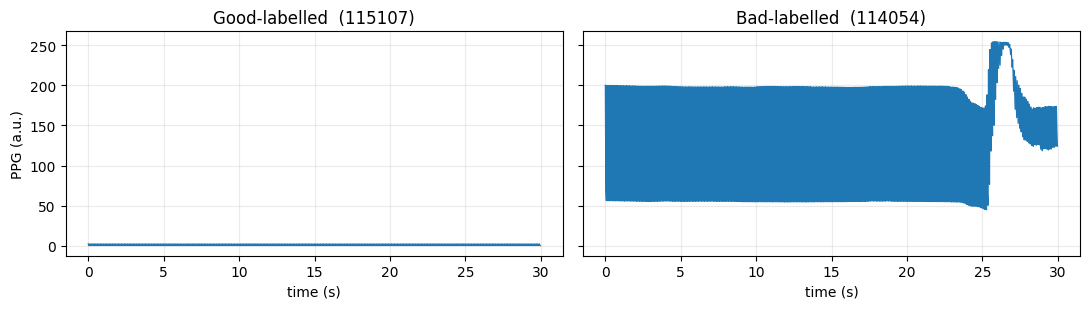

In [3]:
# Plot a clean (good-labelled) recording next to a messy (bad-labelled) one
good_sig, bad_sig = load_ppg(GOOD_ID), load_ppg(BAD_ID)
taxis = lambda s: np.arange(len(s)) / FS_PPG
fig, axl, axr = two_panels(f"Good-labelled  ({GOOD_ID})", f"Bad-labelled  ({BAD_ID})")
axl.plot(taxis(good_sig), good_sig, lw=0.9)
axr.plot(taxis(bad_sig), bad_sig, lw=0.9)
for ax in (axl, axr):
    ax.set_xlabel("time (s)")
axl.set_ylabel("PPG (a.u.)")
plt.tight_layout(); plt.show()

In [4]:
# Skewness SQI: band-pass ONLY to compute the score, then measure asymmetry
_bp_b, _bp_a = butter(2, [0.5, 5], btype="band", fs=FS_PPG)


def ppg_skew_sqi(sig, fs=FS_PPG):
    x = sig - sig.mean()
    x = filtfilt(_bp_b, _bp_a, x)
    x = x[fs:-fs]                 # drop 1 s filter-transient at each edge
    return skew(x)


print(f"Good-labelled {GOOD_ID}:  skew = {ppg_skew_sqi(load_ppg(GOOD_ID)):+.2f}")
print(f"Bad-labelled  {BAD_ID}:  skew = {ppg_skew_sqi(load_ppg(BAD_ID)):+.2f}")

Good-labelled 115107:  skew = +2.08
Bad-labelled  114054:  skew = -2.74


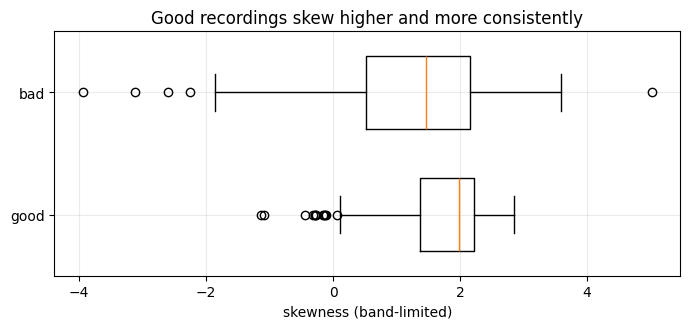

median skew  good = +1.99   bad = +1.47


In [5]:
# Payoff: does skewness agree with the expert labels across many records?
rng = np.random.default_rng(0)
good_ids = [i for i in labels if labels[i] == 1]
bad_ids  = [i for i in labels if labels[i] == 0]
sample = lambda ids: [ppg_skew_sqi(load_ppg(i))
                      for i in rng.choice(ids, 300, replace=False)]
good_skew, bad_skew = sample(good_ids), sample(bad_ids)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.boxplot([good_skew, bad_skew], vert=False, widths=0.6)
ax.set_yticks([1, 2]); ax.set_yticklabels(["good", "bad"])
ax.set_xlabel("skewness (band-limited)")
ax.set_title("Good recordings skew higher and more consistently")
plt.tight_layout(); plt.show()

print(f"median skew  good = {np.median(good_skew):+.2f}   "
      f"bad = {np.median(bad_skew):+.2f}")

**Heuristic, not a verdict.** Good recordings skew higher and cluster
tightly, bad ones scatter and drift lower, exactly the direction Elgendi
reports. But the distributions overlap: 10-second smartphone clips are hard, and
no single skewness cutoff cleanly separates them. Skewness is a useful *screen*,
not a classifier, and any cutoff you pick here will not transfer unchanged to a
wrist wearable or a different sampling rate.

## 2. ECG &mdash; kurtosis

The data is the
[MIT-BIH Noise Stress Test Database](https://physionet.org/content/nstdb/1.0.0/):
clean ECG (records 118 and 119) with calibrated electrode-motion noise added on
a **known schedule**. Each record is 30 minutes at 360 Hz. The protocol is our
ground truth: the **first 5 minutes are clean**, then noise is added in
**alternating 2-minute blocks** (noisy 5&ndash;7 min, clean 7&ndash;9, noisy
9&ndash;11, &hellip;).

A clean ECG is mostly flat baseline punctuated by tall, narrow QRS spikes, a
heavy-tailed distribution, so its **kurtosis is high**. Motion noise fills in the
baseline and pushes the distribution back toward Gaussian, dropping kurtosis.
Zhao & Zhang (2018) use kurtosis (kSQI) as one index inside a multi-SQI fuzzy
system (alongside qSQI, pSQI, and basSQI), not as a standalone score; we isolate
it here for a one-metric teaching demo, where they also report it is more robust
than skewness for ECG.

One convention to keep straight: `scipy.stats.kurtosis` returns *excess*
kurtosis, so a Gaussian scores 0, not the 3 used by papers that report ordinary
kurtosis. The values and cutoffs below are all SciPy excess-kurtosis; do not
compare them 1:1 against a paper using the other convention.

In [6]:
# Load one noise-stress record, channel MLII (6 dB noise during noisy blocks)
rec = wfdb.rdrecord(str(DATA / "ecg" / "118e06"), channels=[0])
ecg, FS_ECG = rec.p_signal.flatten(), rec.fs
print(f"{len(ecg)/FS_ECG/60:.1f} min @ {FS_ECG} Hz, channel {rec.sig_name[0]}")


def minute(sig, a, b):
    return sig[int(a*60*FS_ECG):int(b*60*FS_ECG)]

30.1 min @ 360 Hz, channel MLII


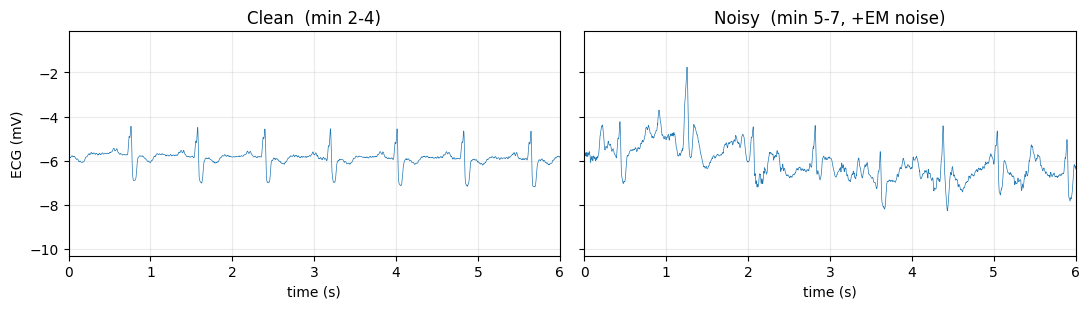

clean  kurtosis = 4.35
noisy  kurtosis = 0.77


In [7]:
# Clean window (min 2-4, before any noise) vs. noisy window (min 5-7)
clean, noisy = minute(ecg, 2, 4), minute(ecg, 5, 7)
tw = np.arange(len(clean)) / FS_ECG
fig, axl, axr = two_panels("Clean  (min 2-4)", "Noisy  (min 5-7, +EM noise)")
axl.plot(tw, clean, lw=0.5)
axr.plot(tw, noisy, lw=0.5)
for ax in (axl, axr):
    ax.set_xlabel("time (s)"); ax.set_xlim(0, 6)
axl.set_ylabel("ECG (mV)")
plt.tight_layout(); plt.show()

print(f"clean  kurtosis = {kurtosis(clean):.2f}")
print(f"noisy  kurtosis = {kurtosis(noisy):.2f}")

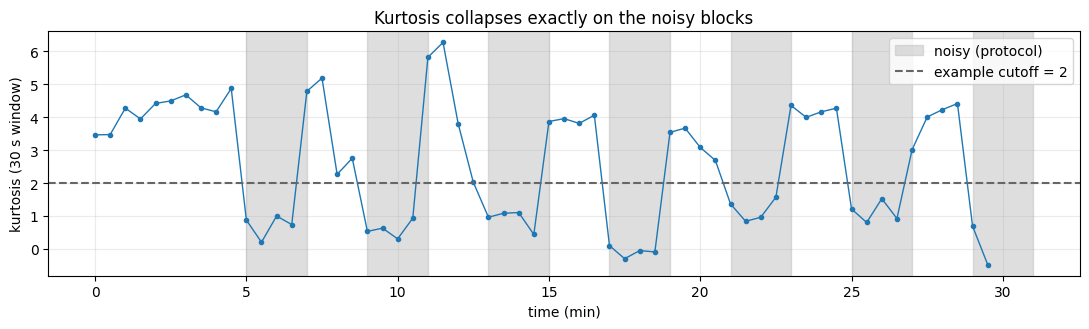

In [8]:
# Payoff: slide kurtosis across the whole record vs. the known noise schedule
win = int(30 * FS_ECG)                       # 30 s windows
centres = np.arange(0, len(ecg) - win, win)
kurt = [kurtosis(ecg[i:i+win]) for i in centres]
mins = centres / FS_ECG / 60

fig, ax = plt.subplots(figsize=(11, 3.4))
# shade the protocol's noisy 2-min blocks (start 5 min, every 4 min)
for start in range(5, 30, 4):
    ax.axvspan(start, start + 2, color="0.75", alpha=0.5,
               label="_" * (start > 5) + "noisy (protocol)")
ax.plot(mins, kurt, marker=".", lw=1)
ax.axhline(2.0, ls="--", color="0.4", label="example cutoff = 2")
ax.set_xlabel("time (min)"); ax.set_ylabel("kurtosis (30 s window)")
ax.set_title("Kurtosis collapses exactly on the noisy blocks")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

**Heuristic, not a verdict.** Kurtosis tracks the noise schedule almost
perfectly: it sits at 4&ndash;5 on clean stretches and falls below 1 inside every
shaded block. The dashed cutoff of 2 separates them here, but that number is tied
to this lead, this heart rate, and this noise type. A different arrhythmia or a
faster rhythm shifts the clean-signal baseline, so recalibrate before trusting a
fixed threshold.

## 3. EMG &mdash; signal-to-noise ratio

The data is [Ninapro DB2](https://ninapro.hevs.ch/instructions/DB2.html),
subject 1: 12-channel forearm EMG at 2 kHz while the subject performs hand
gestures, with a `restimulus` label marking **rest (0)** vs. each **gesture
(1&ndash;17)**. Be clear about what that label is: it marks where muscle activity
is *expected*, an activity label, **not** an expert judgement of signal quality.
There is no single agreed EMG quality index; the field standard is a
**signal-to-noise ratio** comparing muscle activity during a gesture against the
resting baseline:

$$\mathrm{SNR_{dB}} = 20\,\log_{10}\!\frac{\mathrm{RMS_{gesture}}}{\mathrm{RMS_{rest}}}$$

So this check is self-referential rather than validated against good/bad labels:
SNR confirms the signal rises above its own resting baseline where a gesture is
supposed to occur, and a rest segment compared against itself scores near 0 dB.
For a clear illustration we show the single channel that best separates gesture
from rest; a real pipeline would score every channel.

In [9]:
# Load subject 1, exercise 1. restimulus: 0 = rest, 1..17 = gestures.
mat = sio.loadmat(DATA / "emg" / "S1_E1_A1.mat")
emg, restim = mat["emg"], mat["restimulus"].flatten()
FS_EMG = 2000

rest_mask = restim == 0
gestures = list(range(1, int(restim.max()) + 1))
rms = lambda x: np.sqrt(np.mean(x ** 2))
rest_rms = np.sqrt(np.mean(emg[rest_mask] ** 2, axis=0))     # per channel


def gesture_snrs(ch):
    'SNR (dB) of each gesture vs. the resting baseline, on one channel.'
    return np.array([20 * np.log10(rms(emg[restim == g, ch]) / rest_rms[ch])
                     for g in gestures])


# use the channel whose gestures separate best from rest
CH = int(np.argmax([np.median(gesture_snrs(ch)) for ch in range(emg.shape[1])]))
print(f"{emg.shape[1]} channels @ {FS_EMG} Hz; using channel {CH}")


def first_block(mask):
    idx = np.where(mask)[0]
    brk = np.where(np.diff(idx) > 1)[0]
    return idx[0], (idx[brk[0]] if len(brk) else idx[-1])

12 channels @ 2000 Hz; using channel 2


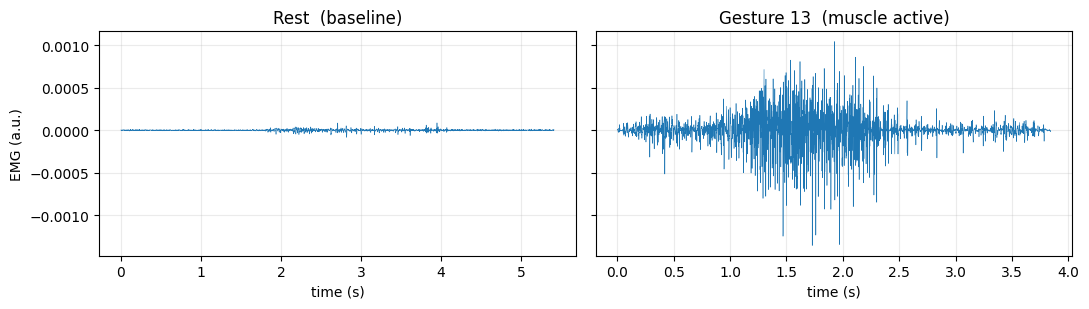

In [10]:
# One resting block next to its strongest gesture block, same channel
G_EX = gestures[int(np.argmax(gesture_snrs(CH)))]
r0, r1 = first_block(rest_mask)
g0, g1 = first_block(restim == G_EX)
rest_seg, gest_seg = emg[r0:r1, CH], emg[g0:g1, CH]

fig, axl, axr = two_panels("Rest  (baseline)", f"Gesture {G_EX}  (muscle active)")
axl.plot(np.arange(len(rest_seg)) / FS_EMG, rest_seg, lw=0.4)
axr.plot(np.arange(len(gest_seg)) / FS_EMG, gest_seg, lw=0.4)
for ax in (axl, axr):
    ax.set_xlabel("time (s)")
axl.set_ylabel("EMG (a.u.)")
plt.tight_layout(); plt.show()

In [11]:
snr_db = lambda sig, ref: 20 * np.log10(rms(sig) / rms(ref))

print(f"gesture {G_EX} vs rest : {snr_db(gest_seg, rest_seg):5.1f} dB")
print(f"rest vs rest      : {snr_db(rest_seg, rest_seg):5.1f} dB  (no signal -> ~0)")

gesture 13 vs rest :  25.6 dB
rest vs rest      :   0.0 dB  (no signal -> ~0)


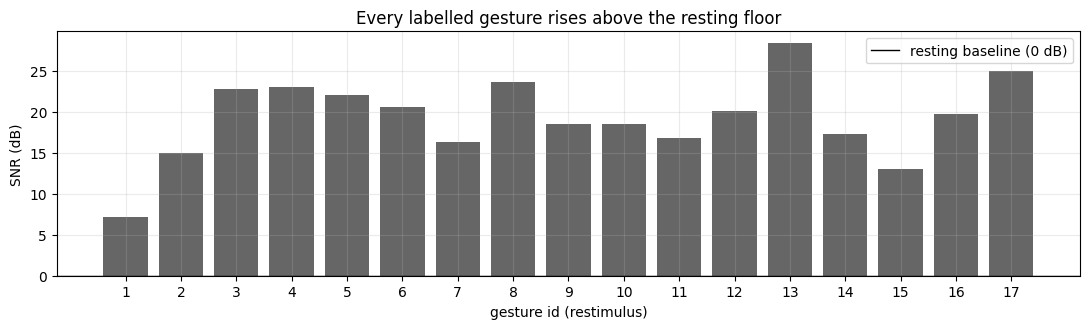

In [12]:
# Payoff: SNR for every gesture, all well above the resting baseline
snrs = gesture_snrs(CH)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(gestures, snrs, color="0.4")
ax.axhline(0, color="k", lw=1, label="resting baseline (0 dB)")
ax.set_xlabel("gesture id (restimulus)"); ax.set_ylabel("SNR (dB)")
ax.set_title("Every labelled gesture rises above the resting floor")
ax.set_xticks(gestures); ax.legend(); plt.tight_layout(); plt.show()

**Heuristic, not a verdict.** Every gesture clears the resting floor, and a
rest-vs-rest comparison sits at 0 dB, so SNR responds where `restimulus` says
activity should be. That confirms *responsiveness*, not signal quality:
`restimulus` marks intended activity, not clean-vs-noisy, so a gesture riding on
a large motion artifact could also post a high SNR. And "good" SNR depends on the
muscle, the electrode placement, and the gesture: a subtle finger movement
legitimately produces a lower ratio than a power grip. Read SNR per channel and
per task, not against one global number.

## 4. EEG &mdash; amplitude threshold + kurtosis

For EEG we use a [Sleep-EDF](https://physionet.org/content/sleep-edfx/) night
fetched through `mne.datasets`, no local file. Scalp EEG lives in a tight
amplitude band (tens of &micro;V), so anything approaching **&plusmn;150
&micro;V** is almost always an artifact rather than brain activity. That flat
**amplitude bound** is the first-line check.

But it has a blind spot: a brief spike, an electrode pop or a single movement
transient, can be obviously non-physiological while never breaching &plusmn;150
&micro;V. Those show up as heavy tails, so we pair the amplitude bound with
**kurtosis** (again SciPy *excess* kurtosis, Gaussian = 0). As we will see, the
two metrics flag *different* epochs, which is exactly why you want both.

In [13]:
# Fetch one night of sleep EEG (cached after the first run)
from mne.datasets.sleep_physionet.age import fetch_data

paths = fetch_data(subjects=[0], recording=[1], on_missing="warn")
raw = mne.io.read_raw_edf(paths[0][0], preload=True, stim_channel=None)
eeg = raw.get_data(picks="EEG Fpz-Cz")[0] * 1e6      # volts -> microvolts
FS_EEG = int(raw.info["sfreq"])
print(f"EEG Fpz-Cz: {len(eeg)/FS_EEG/60:.0f} min @ {FS_EEG} Hz")

# split into 5 s epochs; score each by peak amplitude and by kurtosis
win = 5 * FS_EEG
n_ep = len(eeg) // win
epochs = eeg[:n_ep * win].reshape(n_ep, win)
peak = np.abs(epochs).max(axis=1)
kurt = np.array([kurtosis(e) for e in epochs])

clean_ep = epochs[np.argmin(peak)]        # lowest peak amplitude
amp_ep   = epochs[np.argmax(peak)]        # highest peak amplitude
spike_ep = epochs[np.argmax(kurt)]        # highest kurtosis

EEG Fpz-Cz: 1325 min @ 100 Hz


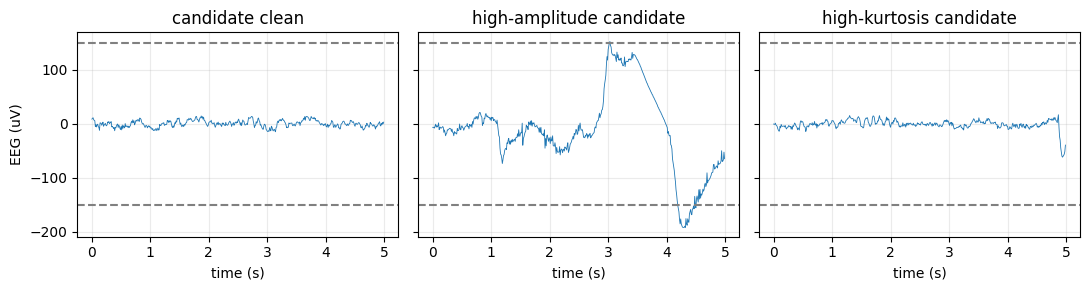

clean cand.    : max|amp| =   14.8 uV   kurtosis =  -0.37
high-amp cand. : max|amp| =  192.0 uV   kurtosis =   0.29
high-kurt cand.: max|amp| =   61.7 uV   kurtosis =  18.17


In [14]:
te = np.arange(win) / FS_EEG
fig, axes = plt.subplots(1, 3, figsize=(11, 3.0), sharey=True)
for ax, ep, title in zip(
        axes, (clean_ep, amp_ep, spike_ep),
        ("candidate clean", "high-amplitude candidate", "high-kurtosis candidate")):
    ax.plot(te, ep, lw=0.6)
    ax.axhline(150, ls="--", color="0.5"); ax.axhline(-150, ls="--", color="0.5")
    ax.set_title(title); ax.set_xlabel("time (s)")
axes[0].set_ylabel("EEG (uV)")
plt.tight_layout(); plt.show()

for name, ep in [("clean cand.", clean_ep), ("high-amp cand.", amp_ep),
                 ("high-kurt cand.", spike_ep)]:
    print(f"{name:15s}: max|amp| = {np.abs(ep).max():6.1f} uV   "
          f"kurtosis = {kurtosis(ep):6.2f}")

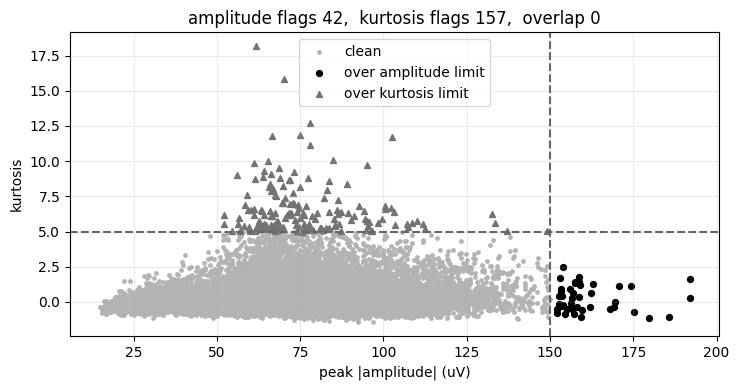

In [15]:
# Payoff: the two thresholds catch two different artifact families
AMP_LIMIT, KURT_LIMIT = 150, 5
by_amp, by_kurt = peak > AMP_LIMIT, kurt > KURT_LIMIT

fig, ax = plt.subplots(figsize=(7.5, 4))
ok = ~(by_amp | by_kurt)
ax.scatter(peak[ok], kurt[ok], s=6, color="0.7", label="clean")
ax.scatter(peak[by_amp], kurt[by_amp], s=18, color="k", label="over amplitude limit")
ax.scatter(peak[by_kurt], kurt[by_kurt], s=18, color="0.45", marker="^",
           label="over kurtosis limit")
ax.axvline(AMP_LIMIT, ls="--", color="0.4")
ax.axhline(KURT_LIMIT, ls="--", color="0.4")
ax.set_xlabel("peak |amplitude| (uV)"); ax.set_ylabel("kurtosis")
ax.set_title(f"amplitude flags {by_amp.sum()},  kurtosis flags {by_kurt.sum()},  "
             f"overlap {int((by_amp & by_kurt).sum())}")
ax.legend(); plt.tight_layout(); plt.show()

**Heuristic, not a verdict.** The two thresholds barely overlap: the
&plusmn;150 &micro;V bound catches large, slow artifacts, while kurtosis catches
brief spikes that stay well inside the amplitude limit. An amplitude-only check
would wave those spikes through. Both numbers are conventions, not physics:
pediatric EEG, high-amplitude slow-wave sleep, and different reference montages
all shift the safe range, so re-tune both per setup.

## Takeaways

Four signals, four one-line metrics, one habit: **assess before you trust.**

- **PPG &rarr; skewness**, **ECG &rarr; kurtosis**, **EMG &rarr; SNR**,
  **EEG &rarr; amplitude threshold + kurtosis**.
- Each metric behaved as its literature predicts: PPG skewness tracked the expert
  good/bad labels, ECG kurtosis tracked the known noise schedule, EMG SNR rose
  where a gesture was expected, and the EEG thresholds flagged distinct epoch
  families. Cheap numbers that surface suspect segments before they reach your
  model, though only PPG and ECG here have true quality ground truth to check
  against.
- Every threshold here is a **heuristic that drifts** across devices, subjects,
  and sampling rates. Calibrate on your own data; never ship a borrowed cutoff.

None of this cleaned a single sample. Quality assessment tells you *whether* to
trust a signal; what you do about the bad parts is a separate decision.